# Blueberry Harvest Forecasting: Phenological Simulation + Synthetic CPF Curves

**Context:** this is a from-scratch Python reconstruction of the core logic behind a blueberry
harvest forecasting pipeline I originally built in R for agricultural planning (as Head of Data
Science at an agro-export company). The original R codebase is no longer available to me; this
notebook re-derives the same methodology in Python, validated against synthetic data so every
step can be run and checked end-to-end.

**Two components, mirroring the original design:**

1. **Phenological simulation** — track flower cohorts week by week as they move through a
   configurable sequence of ripening stages (from "just flowered" to "fully ripe"), convert the
   final-stage population to kilograms using berry weight, and *de-accumulate* the cumulative
   curve into real weekly production. The specific stage taxonomy used at the original company
   is proprietary and not reproduced here — the number of stages and their spacing are
   parameters (`N_STAGES`, `STAGE_SPACING_WEEKS`), so the same code works for a 3-stage, 6-stage,
   or 10-stage ripening model.
2. **Synthetic CPF (Cumulative Probability Function) curves** — fit a parametric ripening curve
   per weekly flower cohort ("promotion") using `scipy.optimize` (L-BFGS-B), then **interpolate**
   the fitted parameters across cohorts to synthesize a ripening curve for a week that has no
   direct historical data — the same idea shown in the original methodology diagram.

All input data below (flower counts, berry weights, ripening rate curves) is **synthetic**,
generated to have realistic agronomic shape (bell-curve flowering, logistic berry-weight growth,
S-shaped ripening curves) — no proprietary farm data is used.

## 1. Setup
Only general-purpose scientific Python — no proprietary dependencies.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats, optimize
from scipy.stats import skewnorm
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
pd.set_option('display.max_columns', 12)

## 2. Synthetic input data

Three inputs feed the simulation, mirroring the original `Funciones_de_Procesamiento_de_Datos`
data-loading step:

- **Flower counts per cohort week** — how many flowers opened each week of the season (bell-shaped,
  peaking mid-season).
- **Berry weight per cohort week** — average mature berry weight, growing through the season
  (logistic curve, small early berries → ~2.1 g at full size).
- **Ripening rate curves per phenological stage** — for a configurable number of stages between
  "just flowered" and "fully ripe", a cumulative probability curve of
  "weeks since flowering → fraction of flowers that have reached this stage", one curve per
  cohort week. The exact number of stages and how far apart they sit is a modeling choice — set
  here as parameters rather than a fixed, named taxonomy, so it stays agronomy-agnostic.

In [2]:
COHORT_WEEKS = list(range(15, 46))   # weeks in which flowers open
MAX_LAG = 20                         # weeks tracked since flowering

# Generic phenological progression: N_STAGES sequential stages from "just flowered" (stage 1)
# to "fully ripe" (stage N). The real taxonomy (specific stage names/count used in production)
# is company-specific and intentionally not reproduced — what matters for the model is that
# stages are ordered and increasingly delayed, which is captured generically below.
N_STAGES = 4
STAGES = [f"stage_{i+1}" for i in range(N_STAGES)]
FINAL_STAGE = STAGES[-1]  # the harvestable / fully-ripe stage

# --- Flower counts: bell curve peaking mid-season ---
def synth_total_flowers(week, peak=28, width=6, scale=50_000):
    return max(0.0, scale * np.exp(-0.5 * ((week - peak) / width) ** 2))

flowers_by_week = {w: round(synth_total_flowers(w), 2) for w in COHORT_WEEKS}

# --- Berry weight: logistic growth through the season ---
def synth_peso_baya(week):
    return round(0.3 + 1.8 / (1 + np.exp(-0.3 * (week - 30))), 2)

peso_by_week = {w: synth_peso_baya(w) for w in COHORT_WEEKS}

# --- Ripening rate curves per stage ---
# Each stage is reached, on average, STAGE_SPACING_WEEKS further out than the previous one;
# uncertainty (std) also grows slightly for later stages. Both are tunable per crop/variety.
STAGE_SPACING_WEEKS = 3.0
STAGE_STD_BASE = 1.0
STAGE_STD_GROWTH = 0.3

MEAN_DELAY = {s: (i + 1) * STAGE_SPACING_WEEKS for i, s in enumerate(STAGES)}
STD_DELAY  = {s: STAGE_STD_BASE + STAGE_STD_GROWTH * i for i, s in enumerate(STAGES)}

# For the final stage specifically, let ripening speed vary slightly by cohort week — earlier,
# colder cohorts ripen a bit slower; later, warmer cohorts ripen faster. This mirrors real
# seasonal effects and gives the interpolation step (section 5) something real to do.
FINAL_STAGE_MEAN = MEAN_DELAY[FINAL_STAGE]
FINAL_STAGE_STD = STD_DELAY[FINAL_STAGE]

def mean_delay_final(week):
    return FINAL_STAGE_MEAN - 0.10 * (week - 30)

def std_delay_final(week):
    return FINAL_STAGE_STD + 0.02 * abs(week - 30)

lags = np.arange(0, MAX_LAG + 1)

def build_rate_table(stage, cohort_weeks):
    cols = {}
    for w in cohort_weeks:
        if stage == FINAL_STAGE:
            loc, scale = mean_delay_final(w), std_delay_final(w)
        else:
            loc, scale = MEAN_DELAY[stage], STD_DELAY[stage]
        cols[f"Week {w}"] = stats.norm.cdf(lags, loc=loc, scale=scale)
    return pd.DataFrame(cols)

rate_tables = {s: build_rate_table(s, COHORT_WEEKS) for s in STAGES}
rate_tables[FINAL_STAGE].iloc[:6, :5]

,Week 15,Week 16,Week 17,Week 18,Week 19
0,4.221589e-10,3.953360e-10,3.697272e-10,3.453057e-10,3.220438e-10
1,6.663515e-09,6.424030e-09,6.188714e-09,5.957618e-09,5.730793e-09
2,8.601433e-08,8.504994e-08,8.407844e-08,8.309982e-08,8.211407e-08
3,9.087392e-07,9.181974e-07,9.279281e-07,9.379424e-07,9.482525e-07
4,7.865991e-06,8.091908e-06,8.328359e-06,8.575992e-06,8.835505e-06
5,5.585574e-05,5.828942e-05,6.087073e-05,6.361085e-05,6.652196e-05


## 3. Core functions (ported from the original R implementation)

These map directly onto the original `get_closest_column`, `load_flowers_information`, and
`apply_rate_changes_with_weights` functions.

In [3]:
def get_closest_column(df, column_name):
    """Find the column in df whose 'Week N' number is closest to column_name's.
    Mirrors the original R get_closest_column — used when a requested week has no
    exact matching cohort column (e.g. at the edges of the season)."""
    cols = list(df.columns)
    if column_name in cols:
        return column_name
    col_numbers = np.array([int(''.join(filter(str.isdigit, c))) for c in cols])
    target_number = int(''.join(filter(str.isdigit, column_name)))
    return cols[int(np.argmin(np.abs(col_numbers - target_number)))]

In [4]:
def build_state_week_df(cohort_weeks):
    """Equivalent of load_flowers_information: one row per cohort week, with flower
    counts and berry weight already attached, and all phenological stages at zero
    (to be filled in by apply_rate_changes_with_weights)."""
    rows = []
    for w in cohort_weeks:
        row = {'week': w, 'totalFlowers': flowers_by_week[w], 'pesoBaya': peso_by_week[w]}
        row.update({f'state_{s}': 0.0 for s in STAGES})
        row['kilograms'] = 0.0
        rows.append(row)
    return pd.DataFrame(rows)

In [5]:
def apply_rate_changes_with_weights(df_state_week, rate_tables, initial_week, target_week):
    """For a fixed target_week, compute — for every flower cohort between initial_week and
    target_week — how far it has progressed through each phenological stage by target_week,
    and the resulting ripe-berry kilograms. Mirrors the original R function of the same name."""
    df = df_state_week.copy()

    for s in STAGES:
        table = rate_tables[s]
        for i in range(initial_week, target_week + 1):
            closest_col = get_closest_column(table, f"Week {i}")
            weeks_between = target_week - i
            rates = table[closest_col].values
            rate_for_week = rates[-1] if weeks_between >= len(rates) else rates[weeks_between]

            row_mask = df['week'] == i
            if not row_mask.any():
                continue
            total_flowers = df.loc[row_mask, 'totalFlowers'].values[0]
            df.loc[row_mask, f'state_{s}'] = round(total_flowers * rate_for_week, 2)

    mask = df['week'].between(initial_week, target_week)
    final_col = f'state_{FINAL_STAGE}'
    df.loc[mask, 'kilograms'] = (df.loc[mask, final_col] * df.loc[mask, 'pesoBaya'] / 1000.0).round(2)
    return df

## 4. Run the simulation: cumulative kilograms → weekly production

For each target week, `apply_rate_changes_with_weights` gives the ripe-berry kilograms
contributed by every cohort so far — summing across cohorts gives **cumulative** kilograms as of
that week. Taking the week-over-week difference (**de-accumulation**) turns that cumulative curve
into the actual weekly harvest estimate — the same two-step logic as the original
`Cálculo de Kilogramos y Desacumulación` section.

In [6]:
df_state_week = build_state_week_df(COHORT_WEEKS)

initial_week = COHORT_WEEKS[0]
index_weeks = list(range(initial_week, COHORT_WEEKS[-1] + 15))  # run past flowering to let ripening finish

kilograms_week = []
for wk in index_weeks:
    df_target = apply_rate_changes_with_weights(df_state_week, rate_tables, initial_week, wk)
    kilograms_week.append(round(df_target['kilograms'].sum(), 2))

kilograms_week = np.array(kilograms_week)
deaccumulation = np.diff(kilograms_week, prepend=0)
deaccumulation[0] = kilograms_week[0]

results = pd.DataFrame({
    'week': index_weeks,
    'kilograms_cumulative': kilograms_week,
    'weekly_production': deaccumulation
})
results.tail(15)

,week,kilograms_cumulative,weekly_production
30,45,504.32,57.97
31,46,557.68,53.36
32,47,604.95,47.27
33,48,645.22,40.27
34,49,678.32,33.10
35,50,704.49,26.17
36,51,724.53,20.04
37,52,739.30,14.77
38,53,749.80,10.50
39,54,757.03,7.23


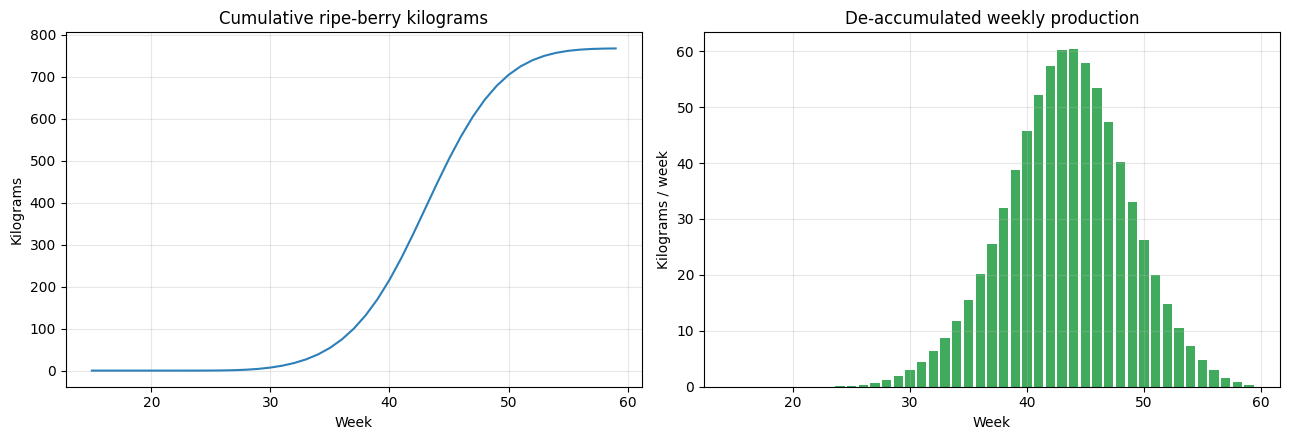

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(results['week'], results['kilograms_cumulative'], color='#2c7fb8')
axes[0].set_title('Cumulative ripe-berry kilograms')
axes[0].set_xlabel('Week'); axes[0].set_ylabel('Kilograms')
axes[0].grid(alpha=0.3)

axes[1].bar(results['week'], results['weekly_production'], color='#41ab5d')
axes[1].set_title('De-accumulated weekly production')
axes[1].set_xlabel('Week'); axes[1].set_ylabel('Kilograms / week')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Synthetic CPF curves: filling gaps between cohorts

Not every cohort week has enough historical data to build a reliable ripening curve directly.
The original methodology (see diagram below) handles this by:

1. Fitting each *available* cohort's ripening curve with a small set of distribution parameters
   (mean, std, skew, kurtosis) using an optimizer (**L-BFGS-B**).
2. **Interpolating** those parameters across cohort weeks.
3. Using the interpolated parameters to generate a **synthetic CPF curve** for any week — including
   ones with no direct data.

```
CPF (curvas de probabilidad acumulada)
        |
Metodo de Optimización (L-BFGS-B)
        |
  mean · std · skew · kurtosis  +  Semanas Requeridas
        |
   Metodo de Interpolación
        |
  mean · std · skew · kurtosis (sintéticos)
        |
      CPF Sintéticas
```

This notebook demonstrates the idea with a **skew-normal** distribution (3 shape parameters:
skew, loc, scale — a simplified stand-in for the original's 4-parameter mean/std/skew/kurtosis
fit, which likely used a more flexible family such as Johnson SU). The mechanism — fit per cohort,
then interpolate — is the same.

In [8]:
def fit_skewnorm_cdf(target_cdf, lags):
    """Fit a skew-normal CDF to an empirical/target cumulative ripening curve via L-BFGS-B."""
    def loss(params):
        a, loc, scale = params
        if scale <= 0:
            return 1e6
        pred = skewnorm.cdf(lags, a, loc=loc, scale=scale)
        return np.sum((pred - target_cdf) ** 2)

    x0 = [0.0, lags[np.argmin(np.abs(target_cdf - 0.5))], 2.0]
    res = optimize.minimize(
        loss, x0, method='L-BFGS-B',
        bounds=[(-10, 10), (0, MAX_LAG), (0.1, 10)]
    )
    return res.x  # (skew, loc, scale)

# Fit curves for a handful of "known" cohort weeks, on the final (fully-ripe) stage
known_weeks = [18, 26, 34, 42]
fitted_params = {w: fit_skewnorm_cdf(rate_tables[FINAL_STAGE][f"Week {w}"].values, lags) for w in known_weeks}

pd.DataFrame(fitted_params, index=['skew', 'loc', 'scale']).T

,skew,loc,scale
18,0.081775,13.060562,2.144540
26,0.182299,12.113953,2.000607
34,-0.182299,11.886047,2.000607
42,-0.081775,10.939438,2.144540


In [9]:
# Interpolate the fitted parameters to synthesize a ripening curve for week 30,
# which was deliberately left out of the "known" set above.
known_weeks_arr = np.array(known_weeks)
param_matrix = np.array([fitted_params[w] for w in known_weeks])

target_week_synth = 30
synth_skew, synth_loc, synth_scale = [
    np.interp(target_week_synth, known_weeks_arr, param_matrix[:, k]) for k in range(3)
]

synth_cdf = skewnorm.cdf(lags, synth_skew, loc=synth_loc, scale=synth_scale)
synth_pdf = skewnorm.pdf(lags, synth_skew, loc=synth_loc, scale=synth_scale)

# For validation only: compare against the "real" curve for week 30 (available here because
# the input data is synthetic — in production this would be genuinely unobserved).
real_cdf = rate_tables[FINAL_STAGE][f"Week {target_week_synth}"].values
mae = np.mean(np.abs(synth_cdf - real_cdf))
print(f"Synthetic vs. real CDF — mean absolute error: {mae:.4f}")

Synthetic vs. real CDF — mean absolute error: 0.0037


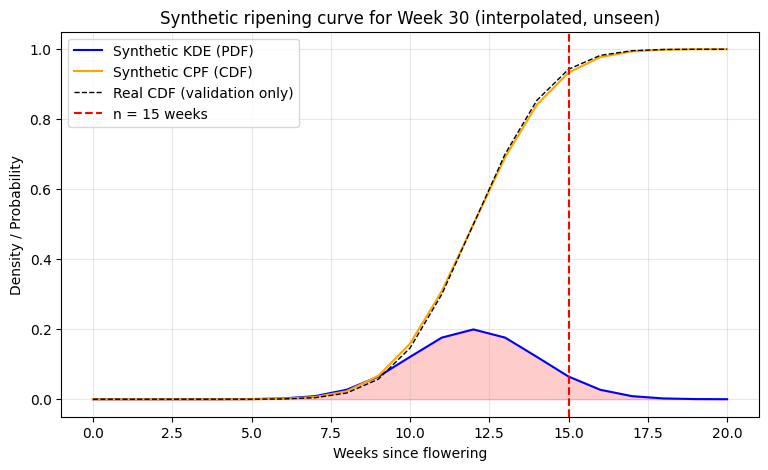

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lags, synth_pdf, color='blue', label='Synthetic KDE (PDF)')
ax.plot(lags, synth_cdf, color='orange', label='Synthetic CPF (CDF)')
ax.plot(lags, real_cdf, color='black', linestyle='--', linewidth=1, label='Real CDF (validation only)')
ax.axvline(15, color='red', linestyle='--', label='n = 15 weeks')
ax.fill_between(lags, synth_pdf, alpha=0.2, color='red')
ax.set_title(f'Synthetic ripening curve for Week {target_week_synth} (interpolated, unseen)')
ax.set_xlabel('Weeks since flowering'); ax.set_ylabel('Density / Probability')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 6. Export results

Final step, mirroring the original `Almacenamiento y Exportación de Resultados` chapter:
write the weekly forecast to Excel with `pandas.ExcelWriter`, ready to hand to planning/logistics.

In [11]:
results.to_excel('blueberry_forecast_results.xlsx', sheet_name='Weekly Forecast', index=False)
print("Saved blueberry_forecast_results.xlsx")
results.head()

Saved blueberry_forecast_results.xlsx


,week,kilograms_cumulative,weekly_production
0,15,0.0,0.0
1,16,0.0,0.0
2,17,0.0,0.0
3,18,0.0,0.0
4,19,0.0,0.0


## Limitations & what's simplified vs. the original

- **Synthetic inputs only.** All flower counts, berry weights, and ripening curves here are
  generated to have realistic *shape*, not fitted to real farm data.
- **Generic stage taxonomy.** The number of phenological stages, their names, and their spacing
  are the original company's proprietary classification and are not reproduced here. The stage
  count/spacing are exposed as parameters (`N_STAGES`, `STAGE_SPACING_WEEKS`) instead, so the same
  pipeline generalizes to any number of stages for any crop.
- **Single parcel, single variety.** The original processed dozens of named parcels
  (`P62, P64, P66A, ...`) split by winter/summer season; this notebook demonstrates the
  mechanism on one synthetic cohort series.
- **3-parameter fit instead of 4.** The original methodology diagram calibrates
  mean/std/skew/**kurtosis**; this notebook fits skew-normal (skew/loc/scale) for clarity. A
  4-parameter family (e.g. Johnson SU) would be a direct extension.
- **Random Forest seasonal model not reconstructed.** The original also included a Random Forest
  regression over ISO week with seasonal (summer/autumn/winter/spring) bands — omitted here since
  no source code or feature definitions were available to reconstruct it faithfully.